# ✈️ DelayPredict — 03b XGBoost

**Goal:** Train an XGBoost classifier and compare it against the baseline (Logistic Regression) and Random Forest.

This notebook is **self-contained** — it loads raw data and performs all feature engineering internally.  
No dependency on previous notebooks at runtime, except `baseline_metrics.csv` and `rf_metrics.csv` for the comparison table.

---
**Input:** `data/raw/airlines_delay.csv`  
**Input (optional):** `data/processed/baseline_metrics.csv`, `data/processed/rf_metrics.csv`  
**Output:** `models/xgb_model.pkl`, `data/processed/xgb_metrics.csv`  
**MLflow:** Run is logged automatically at the end of this notebook  

---
**Why XGBoost?**  
XGBoost (Extreme Gradient Boosting) builds trees **sequentially** — each tree corrects the errors of the previous one.  
This often outperforms Random Forest, especially on tabular data, at the cost of slightly more complexity.

## 1. Setup and Imports

In [253]:
# Install dependencies if not already present
import subprocess
subprocess.run(["pip", "install", "mlflow", "xgboost"], check=True)


CompletedProcess(args=['pip', 'install', 'mlflow', 'xgboost'], returncode=0)

In [254]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

from xgboost import XGBClassifier

import joblib
import mlflow
import mlflow.sklearn

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42


## 2. Load Raw Data

Always loads from the **raw dataset** and performs feature engineering itself.  
This keeps the notebook fully self-contained and independent of `01_eda.ipynb`.

In [255]:
RAW_PATH = Path("../data/raw/airlines_delay.csv")

if not RAW_PATH.exists():
    raise FileNotFoundError(
        f"Raw dataset not found at {RAW_PATH}.\n"
        "Please place airlines_delay.csv in data/raw/"
    )

df = pd.read_csv(RAW_PATH)

print("Source :", RAW_PATH)
print("Shape  :", df.shape)
display(df.head())


Source : ..\data\raw\airlines_delay.csv
Shape  : (539383, 9)


,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,1,CO,269,SFO,IAH,3,15,205,1
1,2,US,1558,PHX,CLT,3,15,222,1
2,3,AA,2400,LAX,DFW,3,20,165,1
3,4,AA,2466,SFO,DFW,3,20,195,1
4,5,AS,108,ANC,SEA,3,30,202,0


## 3. Feature Engineering

Same feature engineering as `03a_random_forest.ipynb`.

| Raw Column | Action | Reason |
|---|---|---|
| `Time` | `// 60` → `DepartureHour` | Time is minutes since midnight (0–1439) |
| `Route` | `AirportFrom + '-' + AirportTo` | Captures combined origin-destination delay pattern |
| `id`, `Flight`, `Time` | Drop | Not needed for modeling |

In [256]:
df["DepartureHour"] = df["Time"] // 60

# Route captures the specific origin-destination delay pattern
df["Route"] = df["AirportFrom"] + "-" + df["AirportTo"]

DROP_COLS = ["id", "Flight", "Time"]
df = df.drop(columns=DROP_COLS)

print("Columns after feature engineering:", df.columns.tolist())
print("Shape:", df.shape)
display(df.head())


Columns after feature engineering: ['Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Length', 'Delay', 'DepartureHour', 'Route']
Shape: (539383, 8)


,Airline,AirportFrom,AirportTo,DayOfWeek,Length,Delay,DepartureHour,Route
0,CO,SFO,IAH,3,205,1,0,SFO-IAH
1,US,PHX,CLT,3,222,1,0,PHX-CLT
2,AA,LAX,DFW,3,165,1,0,LAX-DFW
3,AA,SFO,DFW,3,195,1,0,SFO-DFW
4,AS,ANC,SEA,3,202,0,0,ANC-SEA


## 4. Features and Target

**Target:** `Delay` — 1 if the flight arrived more than 15 minutes late, 0 otherwise.

In [257]:
TARGET = "Delay"

X = df.drop(columns=[TARGET])  # feature matrix
y = df[TARGET]                  # target vector (0 = no delay, 1 = delay)

print("Features:", X.columns.tolist())
print("X shape :", X.shape)
print()

# Class distribution
dist = y.value_counts(normalize=True).mul(100).round(1).rename("% share")
print("Target distribution:")
display(dist)


Features: ['Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Length', 'DepartureHour', 'Route']
X shape : (539383, 7)

Target distribution:


Delay
0    55.5
1    44.5
Name: % share, dtype: float64

## 5. Feature Types

**Key difference from `03a_random_forest.ipynb`:**  
XGBoost supports native categorical features via `enable_categorical=True`.  
Instead of pre-encoding (OHE or TargetEncoder), we pass raw categories directly to XGBoost.  
XGBoost then learns the **optimal partition** of categories at each split during training —  
this is more powerful than any fixed pre-encoding scheme.

| Feature | Type | Reason |
|---|---|---|
| Airline | Categorical (native) | XGBoost learns optimal splits across 18 carriers |
| AirportFrom | Categorical (native) | XGBoost learns optimal splits across 293 airports |
| AirportTo | Categorical (native) | XGBoost learns optimal splits across 293 airports |
| Route | Categorical (native) | XGBoost learns optimal splits across ~2000 routes |
| DayOfWeek | Categorical (native) | XGBoost learns optimal splits across 7 days |
| Length | Numeric | passthrough |
| DepartureHour | Numeric | passthrough |

In [258]:
# Categorical features — passed to XGBoost as native categoricals
# XGBoost will learn the optimal grouping at each tree split
CATEGORICAL = ["Airline", "AirportFrom", "AirportTo", "Route", "DayOfWeek"]

# Numeric features — standard floats
NUMERIC = ["Length", "DepartureHour"]

ALL_FEATURES = NUMERIC + CATEGORICAL

assert all(f in X.columns for f in ALL_FEATURES), \
    "Feature mismatch — check dataset columns."

print("Categorical (native):", CATEGORICAL)
print("Numeric             :", NUMERIC)


Categorical (native): ['Airline', 'AirportFrom', 'AirportTo', 'Route', 'DayOfWeek']
Numeric             : ['Length', 'DepartureHour']


## 6. Train / Test Split

- **80 / 20** split — same ratio as baseline and Random Forest for a fair comparison
- `stratify=y` — preserves class ratio in both splits
- `random_state=42` — same seed across all notebooks for identical splits

In [259]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,  # ensures same class ratio in train and test
)

# Confirm delay rate is consistent across splits
print(f"Train: {X_train.shape}  |  delay rate: {y_train.mean():.3f}")
print(f"Test : {X_test.shape}   |  delay rate: {y_test.mean():.3f}")


Train: (431506, 7)  |  delay rate: 0.445
Test : (107877, 7)   |  delay rate: 0.445


## 7. Preprocessing — Native Categorical Encoding

XGBoost requires categorical columns to have `pandas.Categorical` dtype.  
We use a `FunctionTransformer` inside the pipeline to handle this consistently  
for both training and inference — no manual encoding needed.

In [260]:
def cast_categoricals(X):
    """Cast categorical columns to pandas Categorical dtype for XGBoost native support."""
    X = X.copy()
    for col in CATEGORICAL:
        if col in X.columns:
            X[col] = X[col].astype("category")
    return X

# FunctionTransformer wraps the casting function into a sklearn-compatible step
preprocessor = FunctionTransformer(cast_categoricals)


## 8. XGBoost Model

**Why native categoricals outperform TargetEncoding:**

TargetEncoding reduces each category to a single number (its average delay rate).  
This loses information — two airlines with similar overall delay rates but different  
patterns (e.g. one delays morning flights, one delays evening flights) become identical.

With `enable_categorical=True` and `tree_method='hist'`, XGBoost uses **optimal partition**:  
at each split, it finds the best subset of categories to put left vs right.  
This is theoretically more powerful than any fixed pre-encoding.

**Hyperparameters:**

| Parameter | Value | Reason |
|---|---|---|
| `n_estimators` | 500 | More boosting rounds for complex categorical patterns |
| `learning_rate` | 0.1 | Small steps — more precise with 500 rounds |
| `max_depth` | 6 | Enough depth to capture category interactions |
| `subsample` | 0.8 | Row sampling — reduces overfitting |
| `colsample_bytree` | 0.8 | Feature sampling per tree |
| `min_child_weight` | 10 | Minimum samples per leaf — regularization |
| `tree_method` | hist | Required for native categorical support |
| `enable_categorical` | True | Activates optimal partition splits |

In [261]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=500,          # boosting rounds
        learning_rate=0.1,        # small steps — more precise with 500 rounds
        max_depth=6,               # depth for capturing category interactions
        subsample=0.8,             # row sampling — reduces overfitting
        colsample_bytree=0.8,      # feature sampling per tree
        min_child_weight=10,       # minimum samples per leaf
        tree_method="hist",        # required for native categorical support
        enable_categorical=True,   # XGBoost learns optimal category splits
        eval_metric="logloss",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])

xgb_pipeline.fit(X_train, y_train)
print("XGBoost trained successfully.")


XGBoost trained successfully.


## 9. Evaluate

Evaluate XGBoost on the held-out test set.

In [262]:
y_pred_xgb  = xgb_pipeline.predict(X_test)
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]  # probability of delay

xgb_metrics = {
    "Accuracy" : accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb, zero_division=0),
    "Recall"   : recall_score(y_test, y_pred_xgb, zero_division=0),
    "F1"       : f1_score(y_test, y_pred_xgb, zero_division=0),
    "ROC-AUC"  : roc_auc_score(y_test, y_proba_xgb),
}

print("XGBoost metrics:")
for k, v in xgb_metrics.items():
    print(f"  {k:<10}: {v:.4f}")

print()
print(classification_report(
    y_test, y_pred_xgb,
    target_names=["No Delay", "Delay"],
    zero_division=0
))


XGBoost metrics:
  Accuracy  : 0.6690
  Precision : 0.6632
  Recall    : 0.5220
  F1        : 0.5842
  ROC-AUC   : 0.7218

              precision    recall  f1-score   support

    No Delay       0.67      0.79      0.73     59824
       Delay       0.66      0.52      0.58     48053

    accuracy                           0.67    107877
   macro avg       0.67      0.65      0.65    107877
weighted avg       0.67      0.67      0.66    107877



## 10. Comparison Against All Models

Load previously saved metrics from `02_baseline.ipynb` and `03a_random_forest.ipynb`  
and add XGBoost results for a full side-by-side comparison.

In [263]:
BASELINE_METRICS_PATH = Path("../data/processed/baseline_metrics.csv")
RF_METRICS_PATH       = Path("../data/processed/rf_metrics.csv")

xgb_row = {"model": "XGBoost", **xgb_metrics}

# Collect all available prior results
prior_frames = []
if BASELINE_METRICS_PATH.exists():
    prior_frames.append(pd.read_csv(BASELINE_METRICS_PATH))
else:
    print("baseline_metrics.csv not found — run 02_baseline.ipynb for full comparison.")

if RF_METRICS_PATH.exists():
    prior_frames.append(pd.read_csv(RF_METRICS_PATH))
else:
    print("rf_metrics.csv not found — run 03a_random_forest.ipynb for full comparison.")

# Build comparison table
comparison_df = pd.concat(
    prior_frames + [pd.DataFrame([xgb_row])],
    ignore_index=True
)

display(comparison_df.round(4))


,model,Accuracy,Precision,Recall,F1,ROC-AUC
0,DummyClassifier,0.5546,0.0000,0.0000,0.0000,0.5000
1,LogisticRegression,0.6464,0.6345,0.4862,0.5506,0.6921
2,RandomForest,0.6677,0.6707,0.4990,0.5722,0.7205
3,XGBoost,0.6690,0.6632,0.5220,0.5842,0.7218


## 11. Confusion Matrix

- **True Negatives (top-left):** correctly predicted No Delay
- **False Positives (top-right):** predicted Delay, actually No Delay
- **False Negatives (bottom-left):** predicted No Delay, actually Delay ← the costly error
- **True Positives (bottom-right):** correctly predicted Delay

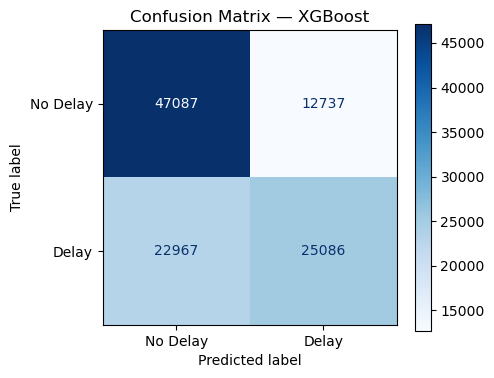

In [264]:
fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=["No Delay", "Delay"],
    cmap="Blues",
    ax=ax,
)
ax.set_title("Confusion Matrix — XGBoost")
plt.tight_layout()
plt.show()


## 12. ROC Curve and Precision-Recall Curve

**ROC Curve** — AUC = 0.5 is random guessing. Higher is better.  
**Precision-Recall Curve** — the dashed line is the no-skill baseline (= delay rate in test set).

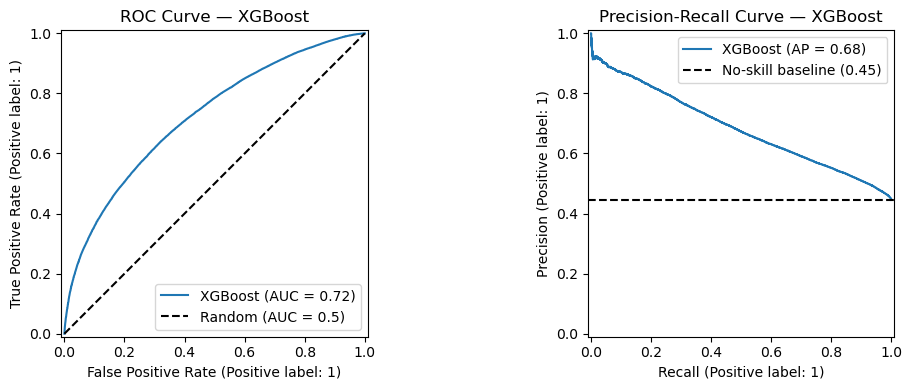

In [265]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_proba_xgb, ax=ax1, name="XGBoost")
ax1.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")
ax1.set_title("ROC Curve — XGBoost")
ax1.legend()

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, y_proba_xgb, ax=ax2, name="XGBoost")
ax2.axhline(y_test.mean(), color="k", linestyle="--",
            label=f"No-skill baseline ({y_test.mean():.2f})")
ax2.set_title("Precision-Recall Curve — XGBoost")
ax2.legend()

plt.tight_layout()
plt.show()


## 13. Feature Importance

XGBoost provides feature importance based on how often each feature is used to split
across all trees. With Target Encoding, feature names are clean and directly interpretable.

Feature importances:


,Feature,Importance
0,DayOfWeek,0.332943
1,Length,0.232256
2,DepartureHour,0.139361
3,Airline,0.115196
4,Route,0.112688
5,AirportFrom,0.043520
6,AirportTo,0.024036


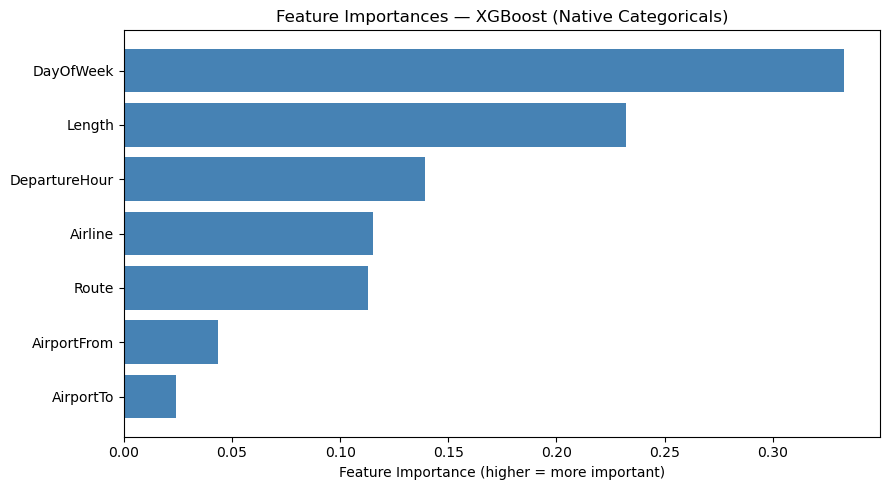

In [266]:
# Feature names match the order passed to XGBoost: numeric first, then categorical
feature_names = NUMERIC + CATEGORICAL
importances   = xgb_pipeline.named_steps["classifier"].feature_importances_

importance_df = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("Feature importances:")
display(importance_df)

plot_df = importance_df.sort_values("Importance")

plt.figure(figsize=(9, 5))
plt.barh(plot_df["Feature"], plot_df["Importance"], color="steelblue")
plt.title("Feature Importances — XGBoost (Native Categoricals)")
plt.xlabel("Feature Importance (higher = more important)")
plt.tight_layout()
plt.show()


## 14. Predicted Probability Distribution

A well-calibrated model pushes probabilities toward 0 and 1.  
Compare this to the distributions from `02_baseline.ipynb` and `03a_random_forest.ipynb`.

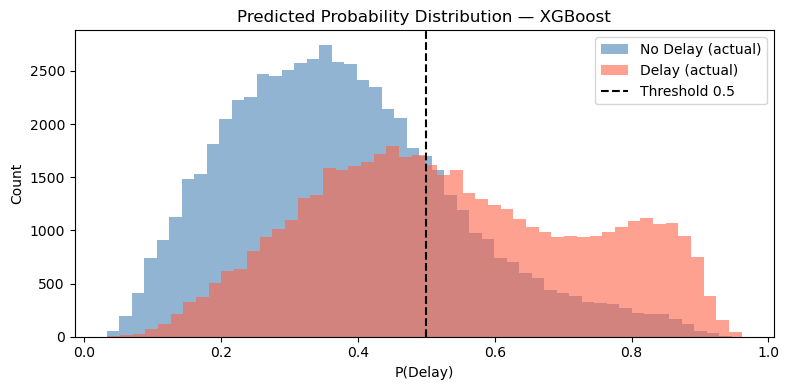

In [267]:
plt.figure(figsize=(8, 4))

# Distribution for flights that were NOT delayed
plt.hist(y_proba_xgb[y_test == 0], bins=50, alpha=0.6,
         label="No Delay (actual)", color="steelblue")

# Distribution for flights that WERE delayed
plt.hist(y_proba_xgb[y_test == 1], bins=50, alpha=0.6,
         label="Delay (actual)", color="tomato")

# Default decision threshold
plt.axvline(0.5, color="black", linestyle="--", label="Threshold 0.5")

plt.title("Predicted Probability Distribution — XGBoost")
plt.xlabel("P(Delay)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


## 15. Save Model and Metrics

- **Model** saved as `.pkl` for use in the FastAPI inference endpoint
- **Metrics CSV** saved for reference

In [268]:
# ── Save trained model ───────────────────────────────────────────────────────
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIR / "xgb_model.pkl"
joblib.dump(xgb_pipeline, MODEL_PATH)
print(f"Model saved   : {MODEL_PATH}")

# ── Save XGBoost metrics CSV ─────────────────────────────────────────────────
OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

xgb_metrics_df = pd.DataFrame([{"model": "XGBoost", **xgb_metrics}])
XGB_METRICS_PATH = OUTPUT_DIR / "xgb_metrics.csv"
xgb_metrics_df.to_csv(XGB_METRICS_PATH, index=False)
print(f"Metrics saved : {XGB_METRICS_PATH}")


Model saved   : ..\models\xgb_model.pkl
Metrics saved : ..\data\processed\xgb_metrics.csv


## 16. MLflow Logging

Log this run to MLflow under the same `DelayPredict` experiment as all other notebooks.  
After running this cell, start the MLflow UI with:
```
mlflow ui
```
Then open `http://localhost:5000` to compare all runs side by side.

In [269]:
mlflow.set_experiment("DelayPredict")

with mlflow.start_run(run_name="XGBoost_NativeCategorical"):

    xgb_clf = xgb_pipeline.named_steps["classifier"]
    mlflow.log_params({
        "model"             : "XGBoost",
        "encoding"          : "NativeCategorical",
        "n_estimators"      : xgb_clf.n_estimators,
        "learning_rate"     : xgb_clf.learning_rate,
        "max_depth"         : xgb_clf.max_depth,
        "subsample"         : xgb_clf.subsample,
        "colsample_bytree"  : xgb_clf.colsample_bytree,
        "min_child_weight"  : xgb_clf.min_child_weight,
        "tree_method"       : xgb_clf.tree_method,
        "random_state"      : RANDOM_STATE,
        "train_size"        : X_train.shape[0],
        "test_size"         : X_test.shape[0],
        "features"          : ", ".join(ALL_FEATURES),
    })

    mlflow.log_metrics({
        "accuracy" : xgb_metrics["Accuracy"],
        "precision": xgb_metrics["Precision"],
        "recall"   : xgb_metrics["Recall"],
        "f1"       : xgb_metrics["F1"],
        "roc_auc"  : xgb_metrics["ROC-AUC"],
    })

    mlflow.sklearn.log_model(xgb_pipeline, artifact_path="model")

    print("MLflow run logged — experiment: 'DelayPredict'")
    print("Run name: XGBoost_NativeCategorical")
    print("Start MLflow UI with: mlflow ui")


2026/04/20 21:31:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 21:31:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run logged — experiment: 'DelayPredict'
Run name: XGBoost_NativeCategorical
Start MLflow UI with: mlflow ui


## 17. Summary

Final results across all models trained so far.

In [270]:
print("XGBOOST RESULTS")
print("=" * 72)
print(f"Train : {X_train.shape[0]:>7,} rows")
print(f"Test  : {X_test.shape[0]:>7,} rows")
print()

# Print full comparison table
metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
print(f"{'Model':<22}" + "".join(f"{m:>10}" for m in metric_cols))
print("-" * 72)
for _, row in comparison_df.iterrows():
    vals = "".join(f"{row[m]:>10.4f}" for m in metric_cols)
    print(f"{row['model']:<22}{vals}")

print()
print("Next: select the best model and proceed to deployment (FastAPI)")


XGBOOST RESULTS
Train : 431,506 rows
Test  : 107,877 rows

Model                   Accuracy Precision    Recall        F1   ROC-AUC
------------------------------------------------------------------------
DummyClassifier           0.5546    0.0000    0.0000    0.0000    0.5000
LogisticRegression        0.6464    0.6345    0.4862    0.5506    0.6921
RandomForest              0.6677    0.6707    0.4990    0.5722    0.7205
XGBoost                   0.6690    0.6632    0.5220    0.5842    0.7218

Next: select the best model and proceed to deployment (FastAPI)
